# 2025 DL Lab4: Semantic Segmentation on BCSS

## Overview

- Semantic segmentation is a computer vision task that aims to classify each pixel in an image into specific objects or regions.

- In this assignment, you will implement a segmentor to classify the specific types of breast cancer lesions.

- The segmentor implemented in this assignment is U-Net, and you are required to construct it from scratch


## Kaggle Competition
Kaggle is an online community of data scientists and machine learning practitioners. Kaggle allows users to find and publish datasets, explore and build models in a web-based data-science environment, work with other data scientists and machine learning engineers, and enter competitions to solve data science challenges.

This assignment use kaggle to calculate your grade.  
Please use this [**LINK**](https://www.kaggle.com/t/250e9c1faedd423faa0eb2b1fe22b733) to join the competition.

## Unzip Data

Unzip BCSS.zip

+ `train` : Contains all training images
+ `val` : Contains all validation images
+ `test` : Contains all test images
+ `train_mask` : Contains all masks for the training set
+ `val_mask` : Contains all masks for the validation set

The train set contains 26,760 images, the val set contains 5,429 images, and the test set contains 4,000 images.

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import torchvision
import torch.nn.functional as F
from torch.autograd import Variable

from PIL import Image
import cv2
cv2.setNumThreads(0)
cv2.ocl.setUseOpenCL(False)
import albumentations as A

import time
import os
from tqdm.notebook import tqdm
from torch.amp import GradScaler, autocast   
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR 
from torch.optim.lr_scheduler import OneCycleLR

# Preprocessing

#### Verify that the paths to the image and mask are correct, and plot the position of the mask on the image.

First, the code establishes DataFrames for the paths of training and validation images, including their corresponding mask paths.

Second, it presents the total number of images in both the training and validation sets.

Third, the code loads a sample training image and its associated mask, visually demonstrating the image and the applied mask in a graphical representation.

In [2]:
TRAIN_IMAGE_PATH = './BCSS/train/'
VAL_IMAGE_PATH = './BCSS/val/'
TRAIN_MASK_PATH = './BCSS/train_mask/'
VAL_MASK_PATH = './BCSS/val_mask/'

In [3]:
n_classes = 3

def create_df(IMAGE_PATH):
    name = []
    for dirname, _, filenames in os.walk(IMAGE_PATH):
        for filename in filenames:
            name.append(filename.split('.')[0])

    return pd.DataFrame({'id': name}, index = np.arange(0, len(name)))

train_df = create_df(TRAIN_IMAGE_PATH)
val_df = create_df(VAL_IMAGE_PATH)


print('Total Train Images: ', len(train_df))
print('Total Val Images: ', len(val_df))

Total Train Images:  26760
Total Val Images:  5429


In [4]:
X_train = train_df['id'].to_numpy()
X_val = val_df['id'].to_numpy()

Image Size (224, 224, 3)
Mask Size (224, 224)


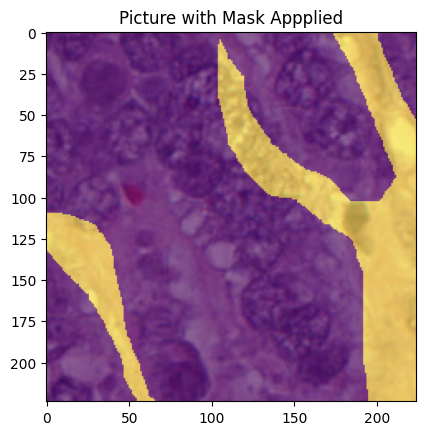

In [5]:
img = Image.open(TRAIN_IMAGE_PATH + train_df['id'][100] + '.png')
mask = Image.open(TRAIN_MASK_PATH + train_df['id'][100] + '.png')
print('Image Size', np.asarray(img).shape)
print('Mask Size', np.asarray(mask).shape)


plt.imshow(img)
plt.imshow(mask, alpha=0.6)
plt.title('Picture with Mask Appplied')
plt.show()

# Loading the Dataset

Define the BCSSDataset for loading the dataset, where each sample comprises an image and its corresponding mask

Build a classs inherit `torch.utils.data.Dataset`.
  
Implement `__init__`, `__getitem__` and `__len__` 3 functions.  

Some operations could be there: setting location of dataset, the method of reading data, label of dataset or transform of dataset.

See [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) for more details

In [6]:
class BCSSDataset(Dataset):

    def __init__(self, img_path, mask_path, X, mean, std, transform=None):
        self.img_path = img_path
        self.mask_path = mask_path
        self.X = X
        self.transform = transform
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_path + self.X[idx] + '.png')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_path + self.X[idx] + '.png', cv2.IMREAD_GRAYSCALE)

        if self.transform is not None:
            aug = self.transform(image=img, mask=mask)
            img = Image.fromarray(aug['image'])
            mask = aug['mask']

        if self.transform is None:
            img = Image.fromarray(img)

        t = T.Compose([T.ToTensor(), T.Normalize(self.mean, self.std)])
        img = t(img)
        mask = torch.from_numpy(mask).long()

        return img, mask

## Data augmentation

Data augmentation are techniques used to increase the amount of data by adding slightly modified copies of already existing data or newly created synthetic data from existing data.

PyTorch use `torchvision.transforms` to do data augmentation.
[You can see all function here.](https://pytorch.org/vision/stable/transforms.html)

In [ ]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

transforms_train = A.Compose([
    A.Resize(224, 224), 
    
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    

    A.ShiftScaleRotate(
        shift_limit=0.0625,
        scale_limit=0.1,      
        rotate_limit=30,      
        p=0.7                 
    ),
    
    
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    
    
    A.CoarseDropout(max_holes=8, max_height=20, max_width=20, fill_value=0, p=0.5),

    
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
])

transforms_val = A.Compose([
    A.Resize(224, 224),
])
train_set = BCSSDataset(TRAIN_IMAGE_PATH, TRAIN_MASK_PATH, X_train, mean, std, transforms_train)
val_set = BCSSDataset(VAL_IMAGE_PATH, VAL_MASK_PATH, X_val, mean, std, transforms_val)

batch_size = 64 


num_workers = 0

train_loader = DataLoader(
    train_set, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)
val_loader = DataLoader(
    val_set, 
    batch_size=batch_size * 2, 
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

e:\project\deeplearning_HW3\deeplearning\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\User\AppData\Local\Temp\ipykernel_37028\125549109.py:21: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
C:\Users\User\AppData\Local\Temp\ipykernel_37028\125549109.py:24: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20, max_width=20, fill_value=0, p=0.5),


In [8]:
train_set[0]

(tensor([[[-2.1179, -0.9534, -2.1179,  ...,  0.2282, -0.8849, -1.2445],
          [-2.1179, -2.1179, -1.6898,  ..., -1.0562, -2.1179, -2.1179],
          [-2.1179, -1.0904, -2.1179,  ..., -2.1179, -1.6384, -0.7822],
          ...,
          [-2.1179, -2.1179, -0.6623,  ..., -2.1179, -2.1179, -2.1179],
          [-0.2684, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -1.4843],
          [-1.3302, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
         [[-1.5805, -1.1604, -2.0357,  ..., -0.1975, -0.8452, -2.0357],
          [-0.2150, -2.0357, -2.0357,  ..., -1.7381, -1.8256, -1.7906],
          [-2.0357, -2.0357, -1.6856,  ..., -2.0357, -0.7402, -0.8978],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -1.3704, -2.0357,  ..., -2.0357, -1.7206,  0.1001],
          [-0.6877, -0.4251, -1.7206,  ..., -2.0357, -2.0357, -2.0357]],
 
         [[-1.8044, -1.8044, -1.5604,  ..., -1.8044, -1.8044, -1.8044],
          [-1.3687, -1.1944,

# U-net

U-net is a fully convolution neural network for image semantic segmentation. Consist of encoder and decoder parts connected with skip connections. Encoder extract features of different spatial resolution (skip connections) which are used by decoder to define accurate segmentation mask. Use concatenation for fusing decoder blocks with skip connections.


![image](https://hackmd.io/_uploads/rJXtsY_Up.png)

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """
    Block with two convolutional blocks
    """

    def __init__(self, in_channels, out_channels, mid_channels=None):
        """
        Double convolution

        :param in_channels: number of in channels for first conv layer
        :param out_channels: number of out channels for last conv layer
        :param mid_channels: number of out channels for first conv layer
        """
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        ########################################################################
        #  TODO:                                                               #
        #  write model that contains 2 conv layer with batch normalization     #
        #  and relu activation function                                        #
        ########################################################################
        self.double_conv = nn.Sequential(
            # Conv -> BatchNorm -> ReLU
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            # Conv -> BatchNorm -> ReLU
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        ########################################################################
        #                           End of your code                           #
        ########################################################################

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """
    Block for down path
    """

    def __init__(self, in_channels, out_channels):
        """
        Down block

        :param in_channels: number of in channels for double conv block
        :param out_channels: number of out channels for double conv block
        """
        super().__init__()
        ########################################################################
        #  TODO:                                                               #
        #  write model which contains pooling and double conv block            #
        ########################################################################
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
        ########################################################################
        #                           End of your code                           #
        ########################################################################

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """
    Block for up path
    """

    def __init__(self, in_channels, out_channels):
        """
        Down block

        :param in_channels: number of in channels for transpose convolution
        :param out_channels: number of out channels for double conv block
        """
        super().__init__()

        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):

        #########################################################################################
        # TODO:                                                                                 #
        # 1. Up-sample the input tensor using transpose convolution                             #
        # 2. Calculate the difference in height and width between x2 and the up-sampled x1      #
        # 3. Pad the up-sampled x1 to match the size of x2                                      #
        # 4. Concatenate x2 and the up-sampled x1 along the channel dimension                   #
        #########################################################################################

        x1 = self.up(x1)

        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1)
        #########################################################################################
        #                           End of your code                                            #
        #########################################################################################


        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        """
        Final convolution block

        :param in_channels: number of in channels for conv layer
        :param out_channels: number of out channels for conv layer
        """
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [10]:
class UNet(nn.Module):
    """UNet model"""
    def __init__(self, n_channels, n_classes):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        #############################################################
        #  implement the model according to the UNet architecture   #
        #############################################################
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024) 

        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
       
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)     
        x2 = self.down1(x1)  
        x3 = self.down2(x2)  
        x4 = self.down3(x3)  
        x5 = self.down4(x4)  
        
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x) 
        return logits
        #############################################################
        #                   End of your code                        #
        #############################################################

In [11]:
model = UNet(n_channels=3, n_classes=3)


In [12]:
model

UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
 

# Training

In this section, you will implement some functions in your training loop. There are several crucial functions you need to implement:

- Pixel Accuracy: Pixel Accuracy measures the percentage of correctly predicted pixels out of the total pixels in the image

- mIoU (Mean Intersection over Union): mIoU evaluates the spatial overlap between the predicted and ground truth segmentation masks for multiple classes.

- Dice Loss: Dice Loss quantifies the dissimilarity between the predicted and ground truth masks, emphasizing the agreement between the two masks

Try to use labeled data design and train a segmentor (Unet) from scratch to predict the mask of a breast cancer lesions image.

In [13]:
def pixel_accuracy(output, mask):
    with torch.no_grad():
        #############################################################################################################
        #  1. Convert the output to class predictions using argmax after applying softmax                           #
        #  2. Create a tensor of binary values indicating correct predictions                                       #
        #  3. Calculate accuracy by dividing the number of correct predictions by the total number of predictions   #
        #############################################################################################################
        preds = torch.argmax(output, dim=1)
        
        correct = (preds == mask)

        accuracy = correct.sum().float() / mask.nelement()
        #############################################################################################################
        #                                      End of your code                                                     #
        #############################################################################################################
    return accuracy.item()

## mIoU

mean Intersection over Union (mIoU), a metric used to evaluate the performance of a segmentation model. It takes predicted masks and ground truth masks as input, computes the IoU for each class, and returns the average IoU across all classes.

![image](https://hackmd.io/_uploads/SkLIbhFL6.png)

In [14]:
def mIoU(pred_mask, mask, n_classes=3, ignore_class=0):
    """
    For batch input, calculates per-image mIoU and averages across the batch.
    """
    with torch.no_grad():
        probs = F.softmax(pred_mask, dim=1)
        preds = torch.argmax(probs, dim=1)  # (B, H, W)

        batch_size = preds.shape[0]
        batch_miou_scores = []

        # Calculate mIoU for each image in the batch (per-image averaging)
        for b in range(batch_size):
            pred_img = preds[b]  # (H, W)
            mask_img = mask[b]   # (H, W)

            iou_list = []
            
            for cls in range(n_classes):
                pred_c = (pred_img == cls)
                label_c = (mask_img == cls)

                intersection = (pred_c & label_c).sum().float()
                union = (pred_c | label_c).sum().float()

                # Skip if union is 0 (class doesn't exist in both GT and Pred)
                if union == 0:
                    continue

                iou = intersection / union

                if cls != ignore_class:
                    iou_list.append(iou)

            # Calculate mIoU for this image
            if len(iou_list) > 0:
                img_miou = torch.stack(iou_list).mean()
                batch_miou_scores.append(img_miou)

        # Return mean of per-image mIoU scores
        if len(batch_miou_scores) > 0:
            return float(torch.stack(batch_miou_scores).mean().item())
        else:
            return 0.0

## Dice Loss

Dice loss is based on Sørensen-Dice coefficient. It measures the overlap between the predicted and target segmentation masks. Dice loss provides a differentiable and smooth measure of segmentation accuracy.

${DiceLoss}(y, \bar p) = 1 - \cfrac{(2y\bar p + \epsilon)}{(y + \bar p + \epsilon)}$

- $y$ represents the ground truth mask.
- $\bar p$ represents the predicted mask.
- $\epsilon$ is a small constant added for numerical stability.

In [ ]:
class DiceLoss(nn.Module):
    """
    Dice loss
    """

    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, weights=None, eps=1e-6): 
        """
        Calculation of dice loss

        :param inputs: model predictions
        :param targets: target values
        :param eps: stability factor, defaults to 1e-6
        :return: loss value
        """
        #
        #######################################
        #        implement dice loss          #
        #######################################
        probs = F.softmax(inputs, dim=1)

        num_classes = inputs.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes=num_classes)
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2)
        probs_flat = probs.view(probs.shape[0], probs.shape[1], -1)
        targets_flat = targets_one_hot.view(targets_one_hot.shape[0], targets_one_hot.shape[1], -1)

        intersection = (probs_flat * targets_flat).sum(dim=2)

        cardinality = probs_flat.sum(dim=2) + targets_flat.sum(dim=2)

        dice = (2. * intersection + eps) / (cardinality + eps)

        if weights is not None:
            dice = dice * weights
        #######################################
        #          End of your code           #
        #######################################
        return 1.0 - dice.mean()

# Training loop

Call train function in a loop.  
Take a break and wait.

In [16]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def fit(epochs, model, train_loader, val_loader, criterion1, criterion2, optimizer, scheduler, 
        patch=False, accumulation_steps=4, validation_frequency=3): 
    torch.cuda.empty_cache()
    train_losses, test_losses = [], []
    val_iou, val_acc = [], []
    train_iou, train_acc = [], []
    lrs = []
    min_loss = np.inf
    not_improve = 0

    model.to(device)
    fit_time = time.time()
    scaler = GradScaler(device='cuda')

    for e in range(epochs):
        since = time.time()
        running_loss = 0
        iou_score = 0
        accuracy = 0
    
        model.train()
        optimizer.zero_grad() 
        for i, data in enumerate(tqdm(train_loader)):
            image, mask = data
            image, mask = image.to(device), mask.to(device)
            with autocast(device_type='cuda', dtype=torch.float16):
                output = model(image)
              
                combined_loss = 0.5 * criterion1(output, mask) + 0.5 * criterion2(output, mask, weights=class_weights)
                loss = combined_loss / accumulation_steps
            scaler.scale(loss).backward()
            iou_score += mIoU(output, mask)
            accuracy += pixel_accuracy(output, mask)
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                lrs.append(get_lr(optimizer))
                scheduler.step()
                optimizer.zero_grad()
            running_loss += combined_loss.item()
      
        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_iou = iou_score / len(train_loader)
        epoch_train_acc = accuracy / len(train_loader)
        train_losses.append(epoch_train_loss)
        train_iou.append(epoch_train_iou)
        train_acc.append(epoch_train_acc)
        
        if (e + 1) % validation_frequency == 0 or (e + 1) == epochs:
            model.eval()
            test_loss = 0
            test_accuracy = 0
            val_iou_score = 0
            with torch.no_grad():
                for i, data in enumerate(tqdm(val_loader)):
                    image, mask = data
                    image, mask = image.to(device), mask.to(device)
                    output = model(image)
                    val_iou_score += mIoU(output, mask)
                    test_accuracy += pixel_accuracy(output, mask)
                    loss = criterion1(output, mask) + criterion2(output, mask)
                    test_loss += loss.item()

            current_val_loss = test_loss / len(val_loader)
            current_val_iou = val_iou_score / len(val_loader)
            current_val_acc = test_accuracy / len(val_loader)
            test_losses.append(current_val_loss)
            val_iou.append(current_val_iou)
            val_acc.append(current_val_acc)

            if current_val_loss < min_loss:
                print(f'Validation Loss Decreased ({min_loss:.4f} ---> {current_val_loss:.4f}). Saving model...')
                min_loss = current_val_loss
                torch.save(model.state_dict(), 'best_model_checkpoint.pt') 
                not_improve = 0 
            else:
                not_improve += 1
                print(f'Loss Not Decrease for {not_improve} time')
                if not_improve >= 7:
                    print('Loss not decrease for 7 times, Stop Training')
                    break
            
            print("Epoch:{}/{}..".format(e+1, epochs), f"Train Loss: {epoch_train_loss:.4f}..", f"Val Loss: {current_val_loss:.4f}..", f"Train mIoU: {epoch_train_iou:.4f}..", f"Val mIoU: {current_val_iou:.4f}..", f"Train Acc: {epoch_train_acc:.4f}..", f"Val Acc: {current_val_acc:.4f}..", "Time: {:.2f}m".format((time.time()-since)/60))
        
        else: 
            test_losses.append(float('nan'))
            val_iou.append(float('nan'))
            val_acc.append(float('nan'))
          
            print("Epoch:{}/{}..".format(e+1, epochs), f"Train Loss: {epoch_train_loss:.4f}..", f"Train mIoU: {epoch_train_iou:.4f}..", f"Train Acc: {epoch_train_acc:.4f}..", "(Skipping validation this epoch)", "Time: {:.2f}m".format((time.time()-since)/60))

    history = {'train_loss' : train_losses, 'val_loss': test_losses, 'train_miou' :train_iou, 'val_miou':val_iou, 'train_acc' :train_acc, 'val_acc':val_acc, 'lrs': lrs}
    print('Total time: {:.2f} m' .format((time.time()- fit_time)/60))
    return history

In [ ]:
################################################################################
#     You can adjust those hyper parameters to loop for max_epochs times       #
###############################################################################
max_lr = 1e-3
epochs = 50
weight_decay = 1e-4
batch_size = 64 
num_workers = 0 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}, num_workers: {num_workers}")


mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

transforms_train = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.0625, 0.0625), rotate=(-30, 30), p=0.7),
    A.CoarseDropout(max_holes=8, max_height=20, max_width=20, fill_value=0, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
])
transforms_val = A.Compose([
    A.Resize(224, 224),
])


train_set = BCSSDataset(TRAIN_IMAGE_PATH, TRAIN_MASK_PATH, X_train, mean, std, transforms_train)
val_set = BCSSDataset(VAL_IMAGE_PATH, VAL_MASK_PATH, X_val, mean, std, transforms_val)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)

val_loader = DataLoader(val_set, batch_size=16, shuffle=False, num_workers=num_workers)
print(f"DataLoaders created with num_workers=0.")


model = UNet(n_channels=3, n_classes=3) 
model.to(device)

class_weights = torch.tensor([0.5, 1.0, 1.0], device=device)
criterion1 = nn.CrossEntropyLoss(weight=class_weights)
criterion2 = DiceLoss() 

optimizer = AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
sched = OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_loader))


print("--- Starting New Training (Single-Process Mode) ---")
history = fit(
    epochs=epochs, 
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion1=criterion1, 
    criterion2=criterion2, 
    optimizer=optimizer, 
    scheduler=sched,
    validation_frequency=3 
)
print("--- Training Finished ---")
################################################################################
#                               End of your code                               #
################################################################################

C:\Users\User\AppData\Local\Temp\ipykernel_37028\90283294.py:22: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20, max_width=20, fill_value=0, p=0.5),


Using device: cuda, num_workers: 0
DataLoaders created with num_workers=0.
--- Starting New Training (Single-Process Mode) ---


  0%|          | 0/419 [00:00<?, ?it/s]

Epoch:1/50.. Train Loss: 0.7896.. Train mIoU: 0.2868.. Train Acc: 0.5768.. (Skipping validation this epoch) Time: 6.13m


  0%|          | 0/419 [00:00<?, ?it/s]

...

  0%|          | 0/419 [00:00<?, ?it/s]

Epoch:49/50.. Train Loss: 0.5634.. Train mIoU: 0.5010.. Train Acc: 0.7684.. (Skipping validation this epoch) Time: 3.96m


  0%|          | 0/419 [00:00<?, ?it/s]

  0%|          | 0/340 [00:00<?, ?it/s]

Validation Loss Decreased (1.1571 ---> 1.1561). Saving model...
Epoch:50/50.. Train Loss: 0.5640.. Val Loss: 1.1561.. Train mIoU: 0.5006.. Val mIoU: 0.5013.. Train Acc: 0.7696.. Val Acc: 0.7534.. Time: 4.47m
Total time: 208.43 m
--- Training Finished ---


#### Visualize accuracy and loss

In [18]:
def plot_loss(history):
    plt.plot(history['val_loss'], label='val', marker='o')
    plt.plot( history['train_loss'], label='train', marker='o')
    plt.title('Loss per epoch'); plt.ylabel('loss');
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

def plot_score(history):
    plt.plot(history['train_miou'], label='train_mIoU', marker='*')
    plt.plot(history['val_miou'], label='val_mIoU',  marker='*')
    plt.title('Score per epoch'); plt.ylabel('mean IoU')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

def plot_acc(history):
    plt.plot(history['train_acc'], label='train_accuracy', marker='*')
    plt.plot(history['val_acc'], label='val_accuracy',  marker='*')
    plt.title('Accuracy per epoch'); plt.ylabel('Accuracy')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

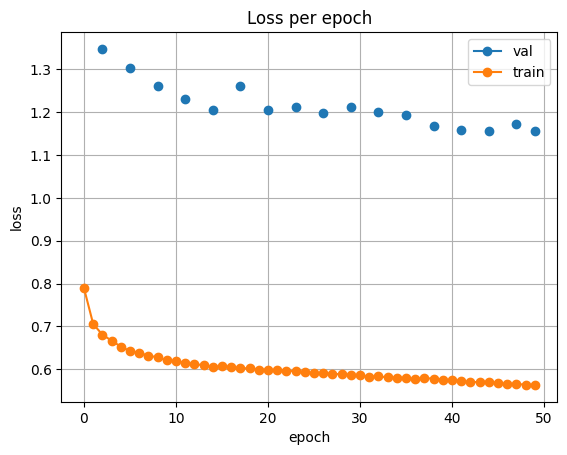

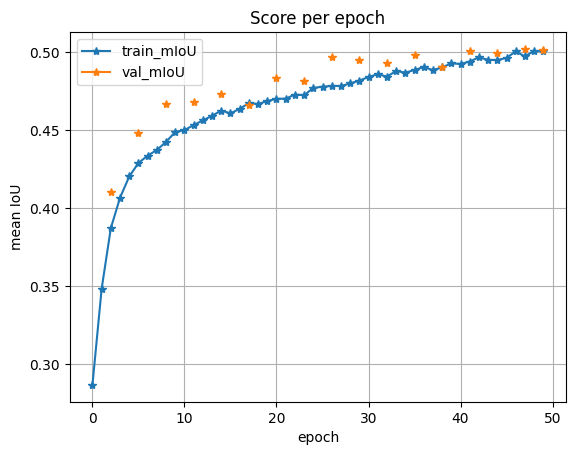

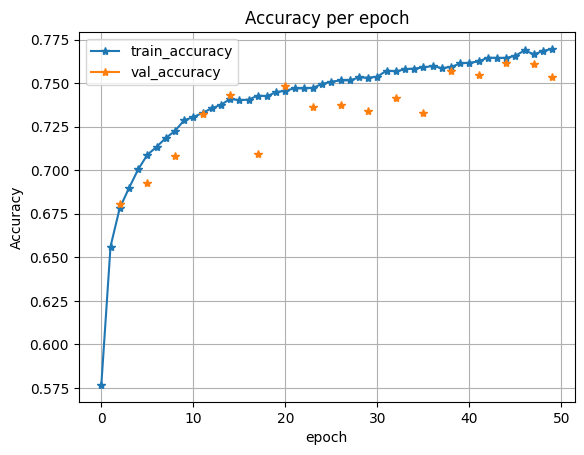

In [19]:
plot_loss(history)
plot_score(history)
plot_acc(history)

### Predict Result

Predict the labesl based on testing set. Upload to [Kaggle](https://www.kaggle.com/t/250e9c1faedd423faa0eb2b1fe22b733).

**How to upload**

1. Click the folder icon in the left hand side of Colab.
2. Right click "result.csv". Select "Download"
3. To kaggle. Click "Submit Predictions"
4. Upload the result.csv
5. System will automaticlaly calculate the accuracy of 50% dataset and publish this result to leaderboard.

In [ ]:
class BCSSTestDataset(Dataset):
    def __init__(self, img_path, X, transform=None):
        self.img_path = img_path
        self.X = X
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image_id = self.X[idx]
        img = cv2.imread(self.img_path + image_id + '.png')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
        if self.transform is not None:
            augmented = self.transform(image=img)
            img = augmented['image']
        return img, image_id


TEST_IMAGE_PATH = './BCSS/test/' 
test_df = create_df(TEST_IMAGE_PATH)
X_test = test_df['id'].to_numpy()
transforms_test = A.Compose([
    A.Resize(224, 224), 
])
test_set = BCSSTestDataset(TEST_IMAGE_PATH, X_test, transform=transforms_test)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, num_workers=0)

model = UNet(n_channels=3, n_classes=3) 
model.load_state_dict(torch.load('best_model_checkpoint.pt'))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]
normalize = T.Normalize(mean=mean, std=std)
results = []

with torch.no_grad():
    
    for images, image_ids in tqdm(test_loader):
        
        
        images = images.to(device).permute(0, 3, 1, 2).float() / 255.0
        images = normalize(images)
        
        
        outputs_original = model(images)
      
        outputs_flipped = model(torch.flip(images, dims=[3]))
    
        outputs_flipped_restored = torch.flip(outputs_flipped, dims=[3])
        avg_softmax = (F.softmax(outputs_original, dim=1) + F.softmax(outputs_flipped_restored, dim=1)) / 2.0
        
        preds = torch.argmax(avg_softmax, dim=1).cpu()

        for i in range(preds.shape[0]):
            image_id = image_ids[i]
            pred_mask_tensor = preds[i]
            pred_mask_string = str(pred_mask_tensor.numpy().tolist()).replace(" ", "")
            
            results.append({'index': image_id, 'pred_mask': pred_mask_string})

submission_df = pd.DataFrame(results)
submission_df = submission_df[['index', 'pred_mask']]
submission_df.to_csv('submission_tta.csv', index=False)

print("\n'submission_tta.csv' with TTA has been generated successfully!")

  0%|          | 0/125 [00:00<?, ?it/s]


'submission_tta.csv' with TTA has been generated successfully!
